In [10]:
import time
import pandas as pd

from craigslist import CraigslistHousing, CraigslistForSale
import requests
from bs4 import BeautifulSoup
import settings
from util import post_listing_to_slack, find_points_of_interest, save_dict_to_file, load_dict_from_file
import os
from datetime import date


In [12]:
# CACHE = {}
# CACHE_DESC = {}

# save_dict_to_file(CACHE, 'cache.pkl')
# save_dict_to_file(CACHE_DESC, 'cache_desc.pkl')

CACHE = load_dict_from_file('cache.pkl')
CACHE_DESC = load_dict_from_file('cache_desc.pkl')
print(f'CACHE has {len(CACHE)} entries CACHE_DESC has {len(CACHE_DESC)} entries')

CACHE has 1096 entries CACHE_DESC has 696 entries


## Scrape

In [13]:
area = settings.AREAS[0]
filter = settings.FILTERS[0]
limit = 500
# Scrapes craigslist area, and returns list of latest listings.
if settings.HOUSE_SEARCH:
    cl_ = CraigslistHousing(site=settings.SITE, area=area, category=settings.CATEGORY, filters=filter)
else:
    cl_ = CraigslistForSale(site=settings.SITE, area=area, category=settings.CATEGORY, filters=filter)
approx_count = cl_.get_results_approx_count()
print(f'Got approximately {approx_count} results')


Got approximately 359 results


In [15]:
# max_results = min(200,approx_count)
# n = 0
sleep=2
gen = cl_.get_results(sort_by='newest', geotagged=True, limit=limit)

for i, result in enumerate(gen):
    if result['url'] not in CACHE:
        print(f"{i}: {result}")
        CACHE[result['url']] = result
        time.sleep(sleep)
    else:
        print(f"{i}: Already cached {result['url']}")




0: Already cached https://seattle.craigslist.org/see/apa/d/seattle-two-tone-cabinetry-pantry-state/7714505966.html
1: Already cached https://seattle.craigslist.org/see/apa/d/seattle-textured-cabinetry-in-two/7714505916.html
2: Already cached https://seattle.craigslist.org/see/apa/d/seattle-energy-efficient-appliances/7714505874.html
3: Already cached https://seattle.craigslist.org/see/apa/d/seattle-balconies-with-belltown-views/7714505842.html
4: Already cached https://seattle.craigslist.org/see/apa/d/seattle-rooftop-deck-ports-for-portable/7714505834.html
5: Already cached https://seattle.craigslist.org/see/apa/d/seattle-south-facing-one-bedroom-plus/7714505823.html
6: Already cached https://seattle.craigslist.org/see/apa/d/seattle-limited-studio-beds-left-look/7714505826.html
7: Already cached https://seattle.craigslist.org/see/apa/d/seattle-professional-on-site/7714505714.html
8: Already cached https://seattle.craigslist.org/see/apa/d/seattle-live-work-loft-ac-wd-24-hr/7714505667.ht

In [84]:



def report_and_clean_duplicates(df, remove_dupes=False):
    """
    Reports duplicates based on the DataFrame's index and the count of NaNs per column.
    Optionally removes duplicates if remove is True.
    
    Parameters:
    - df: DataFrame to analyze and clean.
    - remove_dupes: Boolean flag to indicate whether to remove duplicates.
    
    Returns:
    - DataFrame: Original DataFrame if remove is False; otherwise, DataFrame without duplicates.
    """
    duplicate_indices = df.index[df.index.duplicated()].unique()
    print(f"Duplicate indices: {len(duplicate_indices)}")
    for index in duplicate_indices:
        print(f"Duplicate index: {index}")
    if remove_dupes:
        df = df[~df.index.duplicated(keep='first')]
        print(f"Removed duplicates. New size: {df.shape}")
    nans_per_column = df.isna().sum()
    print("NaNs per column:")
    print(nans_per_column[nans_per_column > 0])
    return df

def format_results_df(res_df):
    col_order = ['name',  'price', 'area', 'error', 'where', 'geotag', 'deleted', 'description', 'url']
    res_df = res_df[col_order]
    res_df = report_and_clean_duplicates(res_df, remove_dupes=True)
    res_df.index = res_df.index.astype(int)
    res_df['price'] = res_df['price'].astype(int)
    res_df = res_df.dropna(subset=['geotag'])
    # res_df['latitude'], res_df['longitude'] = zip(*res_df['geotag'].apply(lambda x: (x[0], x[1])))


    return res_df



In [87]:
v=3

results = CACHE.copy()
res_df = []
for i, (_, result) in enumerate(results.items()):
    # print(i, result)
    result['error'] = ''
    if result.get("where", None) is None:
        print(f'"where" is None for {result["name"]}, should it be skipped?')
        result["error"] = 'no_where'
    if result.get("deleted", False) is True:
        print(f'"deleted" is True for {result["name"]}, should it be skipped?')
        result["error"] = 'is_deleted'
    if any(tok in result.get("name", "").lower() for tok in settings.BLACKLIST_TOKENS):
        # print(f'Skipping blacklisted word in title: {result["name"]}')
        result["error"] = 'blacklisted_name'

    # # Try parsing the price.
    if result.get("price", None) is not None:
        if type(result["price"]) is not int:
            result["price"] = int(result["price"].strip('$').replace(',', ''))

    result["area"] = ""
    if result.get("geotag", None) is not None:
        # Annotate the result with information about the area it's in and points of interest near it.
        result["area"] = find_points_of_interest(result["geotag"], result["where"], result["url"])
        

    # Try parsing description.
    result["description"] = ''
    # try:
    if result["url"] not in CACHE_DESC:
        response = requests.get(result["url"], headers={'User-Agent': settings.USERAGENT})
        if response and response.text:
            CACHE_DESC[result["url"]] = response.text
            soup = BeautifulSoup(response.text, 'html.parser') 
        else:
            print(f'Response is empty for url: {result["url"]}')
            result["error"] = 'empty_description_response'
            soup = None     
    else: 
        soup = BeautifulSoup(CACHE_DESC[result["url"]], 'html.parser')
    # TODO can also parse image urls here and other in post content.
    if soup:
        desc_elm = soup.find('section', {'id': 'postingbody'})
        if desc_elm and desc_elm.text:
            desc = str(desc_elm.text)
        else:
            print(f'Description field is empty for url: {result["url"]}')
            result["error"] = 'empty_description'
    
        result["description"] = desc.replace('QR Code Link to This Post', '').strip()
        # if any(tok in desc.lower() for tok in settings.BLACKLIST_TOKENS):
        #     # print(f'Skipping blacklisted word in description for name: {result["name"]}')
        #     result["error"] = 'blacklisted_description'
    # except Exception as e:
    #     print(f'Description exception: {e}')
    #     result["error"] = f'exception_for_description_{e}'

    print(f"{i}: ${result['price']} in {result['area']} | {result['name']}")
    res_df.append(result)


res_df = pd.DataFrame(res_df).set_index('id', drop=True)
res_df = format_results_df(res_df)
res_df.to_csv(f'results_formatted_v{v}.tsv', sep='\t')
res_df

0: $2070 in bellevue | Fully Furnished and Ready to Move in
1: $2150 in capital hill | West Facing Open 1 Bedroom! Natural Light Just Pours In!
2: $2439 in greenwood | 6 Weeks Free - Stunning 1 Bedroom + Den On Our Bight Southwest Corner
3: $2695 in ballard | 3 bdrm. 2 Full bath unit in a Brick Triplex in Ballard
4: $2695 in belltown | 2BD 2BA apt :: Modern kitchen :: Open concept living :: Belltown area
5: $1830 in renton | TOUR TODAY! Pet Friendly, Close To Transit, Nearby Downtown Apt Homes!
6: $2895 in downtown | Exposed brick walls, Ceiling fans
7: $1695 in capitol hill | Landmark N. Broadway, hardwoods, Parking, Pets
8: $1725 in capitol hill | North Broadway, Hardwoods, Pets, Parking
9: $1895 in eastlake | Light Filled 1 Bedroom on Eastlake- 2 Weeks FREE
10: $1995 in eastlake | Stunning Top Floor Eastlake 1 Bedroom
11: $1700 in eastlake | Charming MFTE 1Bed on Eastlake - 2 Weeks Free
12: $2495 in first hill | $1000 OFF AND PRICE DROP! Enjoy Seattle in your Renovated 2x2 with W/D


,name,price,area,error,where,geotag,deleted,description,url
id,,,,,,,,,
7703290759,Fully Furnished and Ready to Move in,2070,bellevue,,seattle,"(47.5614, -122.1552)",False,Furnished Studio - Only 2 Month Minimum!Take a...,https://seattle.craigslist.org/see/apa/d/belle...
7703290428,West Facing Open 1 Bedroom! Natural Light Just...,2150,capital hill,,seattle,"(47.61633, -122.308397)",False,"Lawrence Lofts1818 E Madison Street, Seattle, ...",https://seattle.craigslist.org/see/apa/d/seatt...
7702741018,6 Weeks Free - Stunning 1 Bedroom + Den On Our...,2439,greenwood,,Greenwood,"(47.691677, -122.356337)",False,"8612 Palatine Ave N, Seattle, WA 98103(Price r...",https://seattle.craigslist.org/see/apa/d/seatt...
7702623614,3 bdrm. 2 Full bath unit in a Brick Triplex in...,2695,ballard,blacklisted_name,"Seattle, Ballard","(47.6691, -122.3691)",False,For rent a 3 bedroom 2 full bathroom unit in a...,https://seattle.craigslist.org/see/apa/d/seatt...
7702173313,2BD 2BA apt :: Modern kitchen :: Open concept ...,2695,belltown,,"Seattle Waterfront, Belltown, Elliott Avenue","(47.612051, -122.347308)",False,The Elliott Pointe Apartments offers unique st...,https://seattle.craigslist.org/see/apa/d/seatt...
...,...,...,...,...,...,...,...,...,...
7714506512,Wood-style plank flooring throughout apartment...,1862,central district,blacklisted_name,Seattle Central District,"(47.59662, -122.312236)",False,Receive up to 8 Weeks Free! This is a 1 Bedroo...,https://seattle.craigslist.org/see/apa/d/seatt...
7714506181,Experience our spacious 1 BR today!,2195,west seattle,,Seattle,"(47.58552, -122.386339)",False,"Windhill, #4051 bd, 1 ba | Available 2/17/24We...",https://seattle.craigslist.org/see/apa/d/seatt...
7714506122,"Spacious floor plans, Quartz counter tops",2235,greenlake,,"Haller Lake, Northgate, Greenlake, Ballard & W...","(47.71251, -122.344467)",False,"Haller Post1130 N 115th St, Seattle, WA, 98133...",https://seattle.craigslist.org/see/apa/d/seatt...


In [88]:
res_df['error'].value_counts()

error
                              1202
blacklisted_name               245
empty_description               24
empty_description_response       4
Name: count, dtype: int64

In [93]:
save_dict_to_file(CACHE, 'cache.pkl')
save_dict_to_file(CACHE_DESC, 'cache_desc.pkl')


In [32]:
res_df = pd.DataFrame(res_df).set_index('id', drop=True)
res_df = format_results_df(res_df)
res_df.to_csv(f'results_formatted_v{v}.tsv', sep='\t')
res_df

,name,price,area,error,where,geotag,deleted,description,url
id,,,,,,,,,
7703290759,Fully Furnished and Ready to Move in,2070,bellevue,blacklisted_description,seattle,"(47.5614, -122.1552)",False,Furnished Studio - Only 2 Month Minimum!Take a...,https://seattle.craigslist.org/see/apa/d/belle...
7703290428,West Facing Open 1 Bedroom! Natural Light Just...,2150,capital hill,blacklisted_description,seattle,"(47.61633, -122.308397)",False,"Lawrence Lofts1818 E Madison Street, Seattle, ...",https://seattle.craigslist.org/see/apa/d/seatt...
7702741018,6 Weeks Free - Stunning 1 Bedroom + Den On Our...,2439,greenwood,blacklisted_description,Greenwood,"(47.691677, -122.356337)",False,"8612 Palatine Ave N, Seattle, WA 98103(Price r...",https://seattle.craigslist.org/see/apa/d/seatt...
7702623614,3 bdrm. 2 Full bath unit in a Brick Triplex in...,2695,ballard,blacklisted_description,"Seattle, Ballard","(47.6691, -122.3691)",False,For rent a 3 bedroom 2 full bathroom unit in a...,https://seattle.craigslist.org/see/apa/d/seatt...
7702173313,2BD 2BA apt :: Modern kitchen :: Open concept ...,2695,belltown,blacklisted_description,"Seattle Waterfront, Belltown, Elliott Avenue","(47.612051, -122.347308)",False,The Elliott Pointe Apartments offers unique st...,https://seattle.craigslist.org/see/apa/d/seatt...
...,...,...,...,...,...,...,...,...,...
7714506512,Wood-style plank flooring throughout apartment...,1862,central district,blacklisted_description,Seattle Central District,"(47.59662, -122.312236)",False,Receive up to 8 Weeks Free! This is a 1 Bedroo...,https://seattle.craigslist.org/see/apa/d/seatt...
7714506181,Experience our spacious 1 BR today!,2195,west seattle,blacklisted_description,Seattle,"(47.58552, -122.386339)",False,"Windhill, #4051 bd, 1 ba | Available 2/17/24We...",https://seattle.craigslist.org/see/apa/d/seatt...
7714506122,"Spacious floor plans, Quartz counter tops",2235,greenlake,blacklisted_description,"Haller Lake, Northgate, Greenlake, Ballard & W...","(47.71251, -122.344467)",False,"Haller Post1130 N 115th St, Seattle, WA, 98133...",https://seattle.craigslist.org/see/apa/d/seatt...


In [94]:
import json
# Used https://geojson.io/#map=11.41/47.6693/-122.3446, pasted below
# see: https://imgur.com/a/VU7Fuv4

import geopandas as gpd
from shapely.geometry import shape
import pandas as pd
from shapely.geometry import Point

# GeoJSON string representing the geofence

# Corrected JSON string representing the geofence as a Polygon
GEOFENCE_JSON = '''
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [-122.40850467368824, 47.6720698561534],
            [-122.34032393873414, 47.69115185135212],
            [-122.27539378508183, 47.67443284835886],
            [-122.3367023365384, 47.62441803881731],
            [-122.40850467368824, 47.6720698561534]
          ]
        ]
      }
    }
  ]
}
'''

def load_geofence_from_json(json_str):
    """
    Load a geofence polygon from a JSON string.
    
    Returns:
    - geofence: Geopandas GeoDataFrame representing the geofence.
    """
    geofence_data = json.loads(json_str)
    polygon = shape(geofence_data['features'][0]['geometry'])
    geofence = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[polygon])
    return geofence

def check_geofence(df, geofence_json):
    """
    For each row in the DataFrame, check if the 'geotag' coordinates are within the geofence.
    
    Parameters:
    - df: DataFrame with a 'geotag' column containing coordinates in (longitude, latitude) format.
    - geofence: Geopandas GeoDataFrame representing the geofence.
    
    Returns:
    - DataFrame: Original DataFrame with a new 'in_geofence' column indicating if each row is within the geofence.
    """
    
    geofence = load_geofence_from_json(geofence_json)
    # df 'geotag' is (lat, long) for some reason...
    # Reverse the coordinates from (longitude, latitude) to (latitude, longitude) and create Point objects
    gdf = gpd.GeoDataFrame(df, geometry=[Point(xy[1], xy[0]) for xy in df['geotag']], crs="EPSG:4326")

    # Perform the spatial join to check if points are within the geofence
    gdf_with_geofence = gpd.sjoin(gdf, geofence, how="left", op="within")
    gdf['in_geofence'] = gdf_with_geofence.index_right.notnull()
    
    return gdf.drop(columns=['geometry'])



In [109]:

picks_df = check_geofence(res_df, GEOFENCE_JSON)


# Filter choices
picks_df=picks_df.loc[picks_df['in_geofence']==True]
picks_df=picks_df.loc[picks_df['deleted']==False]
picks_df=picks_df.loc[picks_df['error']=='']

picks_df.to_csv(f'picks_from_results_formatted_v{v}.tsv', sep='\t')
picks_df

/Users/jk/Library/Python/3.11/lib/python/site-packages/IPython/core/interactiveshell.py:3460: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


,name,price,area,error,where,geotag,deleted,description,url,in_geofence
id,,,,,,,,,,
7703287670,Light Filled 1 Bedroom on Eastlake- 2 Weeks FREE,1895,eastlake,,"Seattle, Eastlake","(47.63832, -122.325937)",False,Light Filled 1 Bedroom on Eastlake- 2 Weeks FR...,https://seattle.craigslist.org/see/apa/d/seatt...,True
7703287583,Stunning Top Floor Eastlake 1 Bedroom,1995,eastlake,,"Seattle, Eastlake","(47.63832, -122.325937)",False,Stunning Top Floor Eastlake 1 Bedroom \n\n\n\n...,https://seattle.craigslist.org/see/apa/d/seatt...,True
7703287552,Charming MFTE 1Bed on Eastlake - 2 Weeks Free,1700,eastlake,,"Seattle, Eastlake","(47.63832, -122.325937)",False,Charming MFTE 1Bed on Eastlake - 2 Weeks Free\...,https://seattle.craigslist.org/see/apa/d/seatt...,True
7703286765,Charming MFTE 1 Bedroom on Eastlake,1735,eastlake,,"Seattle, Eastlake","(47.638372, -122.326069)",False,Charming MFTE 1 Bedroom on Eastlake \n\n\n\n\n...,https://seattle.craigslist.org/see/apa/d/seatt...,True
7699195453,"Cable Ready, Window Coverings, Natural Light",3075,greenlake,,Greenlake,"(47.678804, -122.325617)",False,"6900 East Green Lake Way N, Seattle, WA 98115U...",https://seattle.craigslist.org/see/apa/d/seatt...,True
...,...,...,...,...,...,...,...,...,...,...
7714406048,"Walk-In Closets *, Private, Landscaped Patios *",2135,queen anne,,seattle,"(47.632569, -122.342338)",False,UP TO 8 WEEKS FREE RENT & 3 MONTHS FREE PARKIN...,https://seattle.craigslist.org/see/apa/d/seatt...,True
7714392649,Modern Elegant Living in the heart of UDistrict,2795,university,,University Village,"(47.664504, -122.300891)",False,Up to 6 Weeks Free on Select Homes!*Contact us...,https://seattle.craigslist.org/see/apa/d/seatt...,True
7714391451,24-hour on-line concierge and management servi...,2374,fremont,,Fremont,"(47.650809, -122.342425)",False,"This is a 1 Bedroom, 1 Bath, Approximately 628...",https://seattle.craigslist.org/see/apa/d/seatt...,True


In [115]:
import textwrap

for id, row in picks_df.sort_values('price').iterrows():
    print('\n'+200*'*')
    print(row)
    print()
    print(textwrap.fill(row['description'], width=80))


********************************************************************************************************************************************************************************************************
name           Campus View is leasing out fast, find your fut...
price                                                       1617
area                                         university district
error                                                           
where                                                 U-District
geotag                                  (47.660528, -122.320637)
deleted                                                    False
description    2 weeks free off 2nd month's rent  Welcome to ...
url            https://seattle.craigslist.org/see/apa/d/seatt...
in_geofence                                                 True
Name: 7703241380, dtype: object

2 weeks free off 2nd month's rent  Welcome to Campus View & Avalon on 7th1
bedroom | 1 bath | 600 square feetVisit 

In [99]:
import matplotlib.pyplot as plt

# Set the style globally
plt.style.use('dark_background')



Areas:
area
ballard                29
green lake             17
queen anne             12
ravenna                12
belltown               11
university district    10
eastlake                8
fremont                 8
university              8
wallingford             7
greenlake               6
seattle                 6
greenwood               1
Name: count, dtype: int64


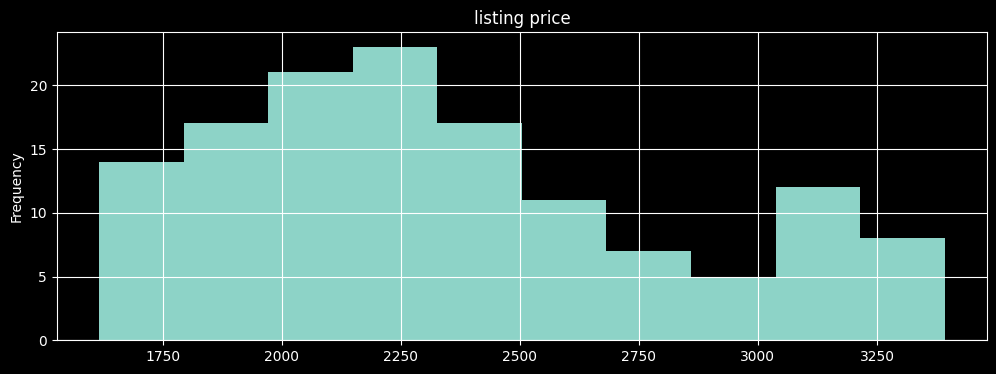

In [108]:
top_n=20
print(f"Areas:\n{picks_df['area'].value_counts().head(top_n)}")

picks_df['price'].plot.hist(figsize=(12, 4), title='listing price', grid=True)
plt.show()


# Other

In [ ]:
# Test
from craigslist import CraigslistHousing
cl_h = CraigslistHousing(site='sfbay', area='sfc', category='roo',
                         filters={'max_price': 1200, 'private_room': True})

# You can get an approximate amount of results with the following call:
# assert cl_h.get_results_approx_count() > 0

MAX_RESULTS = 5
print(f'First {MAX_RESULTS} results (out of {cl_h.get_results_approx_count()})')
for i, result in enumerate(cl_h.get_results(sort_by='newest', geotagged=True)):
    print(result)
    if i > MAX_RESULTS:
        break